---
categories:
- Readings
date: 2026-02-02
lang: en
title: "Bell Sampling on mbqc-iqp circuits"
bibliography: refs.bib
jupyter: python3
keep-ipynb: true
code-fold: true
---

# Summary and question

This page is target on the complexity analysis and practical experiment implementation of the Bell sampling on a iqp/adaptive-iqp circuits.

# Derivation

::: {#lem-ising-Bell .callout-important icon="false"}
## (Bell sampling distribution on Ising partition function)
Consider the Hamiltonian evolution
$$
U_{\rm Ry}(t) = \exp\left[i\sum_{j<k} K_{jk}t\, Z_jZ_k + i\sum_j h_j t\, Z_j\right].
$$
and quantum state $\ket{C} = U_{\rm Ry}(t = 1) \ket{+^n}$.
The Bell sampling distribution is given by:
$$
\begin{align*}
\Pr(\mathbf z,\mathbf x) &= 2^{-3n}\left|\sum_{s\in\{\pm1\}^n}\chi_{\mathbf z}(s)F_{\mathbf x}(s)\right|^2,\; \chi_{\mathbf z}(s):=\prod_i s_i^{z_i}\\
F_{\mathbf x}(s)&:=\exp\left[i\left(\sum_{i<j:\,x_i=x_j}2K_{ij}s_is_j
+\sum_{i:x_i=0}2h_i s_i\right)\right].
\end{align*}
$$
:::

:::{.callout-note collapse="true"}
## Proof (Click to expand)
Take $t = 1$ and state $\ket{C} = U_{\rm Ry}(t) \ket{+^n}$ with 
write $U_{K,h} = e^{i\,\Phi(Z)}$ with Ising energy
$$
\Phi(s) := \sum_{i<j} K_{ij}\, s_i s_j + \sum_i h_i\, s_i,
\qquad s_i  \in \{\pm 1\},
$$
so that $|\psi_{K,h}\rangle = U_{K,h}|+\rangle^{\otimes n}$. Bell sampling on two copies of $|\psi_{K,h}\rangle$ in the standard $X^{\mathbf r_x} Z^{\mathbf r_z}$-labelled Bell basis gives [@hangleiter2024bell]
$$
\begin{align*}
\mathrm{Pr}(\mathbf r) \;&=\; 2^{-n}\,\bigl|\langle \overline{\psi_{K,h}}\,|\,Z^{\mathbf r_z} X^{\mathbf r_x}\,|\psi_{K,h}\rangle\bigr|^{2}\\
&=2^{-n}\,\Bigl|\langle+|^{\otimes n}\, U_{K,h}\,Z^{\mathbf r_z} X^{\mathbf r_x}\, U_{K,h}\,|+\rangle^{\otimes n}\Bigr|^{2}
\end{align*}
$$
Here we have used the fact that $\overline{U_{K,h}} = U_{K,h}^{\dagger}$.
Expand $|+\rangle^{\otimes n} = 2^{-n/2}\sum_y |y\rangle$ and use $U_{K,h}|y\rangle = e^{i\Phi(s(y))}|y\rangle$, together with $Z^{\mathbf r_z} X^{\mathbf r_x}|y\rangle = (-1)^{\mathbf r_z\cdot(y\oplus \mathbf r_x)}\,|y\oplus \mathbf r_x\rangle$. The two $|+\rangle$ envelopes collapse the doubled $y$-sum into a single sum. Defining $s_i(y) = (-1)^{y_i}$, we get the result:
$$
\begin{align*}
&\langle+|\, U_{K,h}\, Z^{\mathbf r_z} X^{\mathbf r_x}\, U_{K,h}\, |+\rangle
\;=\; 2^{-n}\!\sum_{y\in\{0,1\}^n} (-1)^{\mathbf r_z\cdot y}\,
e^{i\bigl[\Phi(s(y))+\Phi(s(y\oplus \mathbf r_x))\bigr]},\\
&= 2^{-n}\!\sum_{y\in\{0,1\}^n} (-1)^{\mathbf r_z\cdot y}\,
e^{i\bigl[\sum_{i<j} K_{ij}\bigl[1+(-1)^{(\mathbf r_x)_i+(\mathbf r_x)_j}\bigr]\, s_i s_j
\;+\; \sum_i h_i\bigl[1+(-1)^{(\mathbf r_x)_i}\bigr]\, s_i\bigr]},\\
&= 2^{-n}\!\sum_{y\in\{0,1\}^n} (-1)^{\mathbf r_z\cdot y}\,
e^{i\bigl[ 2\sum_{i<j:\,(\mathbf r_x)_i = (\mathbf r_x)_j}K_{ij} s_i s_j
+ 2\sum_{i:\,(\mathbf r_x)_i = 0} h_i\, s_i\bigr]},
\end{align*}
$$
where the global phase $(-1)^{\mathbf r_z\cdot \mathbf r_x}$ has been absorbed into the modulus.
Thus the probability of the Bell outcome $\mathbf{r} = (\mathbf{z}, \mathbf{x})$ is:
$$
\begin{align*}
\Pr(\mathbf z,\mathbf x) &= 2^{-3n}\left|\sum_{s\in\{\pm1\}^n}\chi_{\mathbf z}(s)F_{\mathbf x}(s)\right|^2,\; \chi_{\mathbf z}(s):=\prod_i s_i^{z_i}\\
F_{\mathbf x}(s)&:=\exp\left[i\left(\sum_{i<j:\,x_i=x_j}2K_{ij}s_is_j
+\sum_{i:x_i=0}2h_i s_i\right)\right].
\end{align*}
$$
:::

From @lem-ising-Bell, each Bell outcome's probability is still related tothe squared modulus of a **complex Ising partition function**, however, with a reframe effect by both $\mathbf{z}$ and $\mathbf{x}$:

- The $\mathbf x$ separate vertex into two sectors: $\mathcal{S}_0 = \{i: x_i = 0\}$ and $\mathcal{S}_1 = \{i: x_i = 1\}$.
- Only interactions between vertices in the same sector survive, i.e., $K_{ij}$ for $i,j \in \mathcal{S}_0$ or $i,j \in \mathcal{S}_1$.
- The $\mathbf z$ string acts as a parity tag $\prod_i s_i^{z_i}$ inside the partition sum. 


A direct consequence this reframe effect is that the marginal distribution of $\mathbf{x}$ is uniform, i.e., $\mathrm{Pr}(\mathbf x) = {2^{-n}}.$

::: {#lem-ising-gapp .callout-important icon="false"}
## (Maginal of $\mathbf x$ is uniform)
The marginal over $\mathbf x$ is approximately uniform, i.e., $\mathrm{Pr}(\mathbf x) := \sum_{\mathbf z} \mathrm{Pr}(\mathbf z,\mathbf x) = {2^{-n}}.$
:::
:::{.callout-note collapse="true"}
## Proof (Click to expand)
Note that
$$
\begin{align*}
\Pr(\mathbf x)
&=
\sum_{\mathbf z\in\{0,1\}^n}\Pr(\mathbf z,\mathbf x)\\
&=
2^{-3n}
\sum_{\mathbf z}
\left|
\sum_s \chi_{\mathbf z}(s)F_{\mathbf x}(s)
\right|^2\\
&=
2^{-3n}
\sum_{\mathbf z}
\sum_{s,t}
\chi_{\mathbf z}(s)\chi_{\mathbf z}(t)
F_{\mathbf x}(s)\overline{F_{\mathbf x}(t)} .
\end{align*}
$$
Since $\chi_{\mathbf z}(s)$ is the Fourier character on the $\{\pm\}$ field, we conclude:
$$
\sum_{\mathbf z\in\{0,1\}^n}
\chi_{\mathbf z}(s)\chi_{\mathbf z}(t)
=\sum_{\mathbf z}
\prod_i (s_i t_i)^{z_i}=\prod_i(1+s_it_i)=2^n\delta_{s,t}.
$$
Plugging back, we get:
$$
\begin{align*}
\Pr(\mathbf x)&=
2^{-3n}\sum_{s,t}2^n\delta_{s,t}
F_{\mathbf x}(s)\overline{F_{\mathbf x}(t)}\\
&=2^{-2n}
\sum_s |F_{\mathbf x}(s)|^2=
2^{-2n}\cdot 2^n=
2^{-n}.
\end{align*}
$$
Here we use the fact that $|F_{\mathbf x}(s)|=1$ is satisfied for all $s\in\{\pm1\}^n$.
:::

@lem-ising-gapp directly implies that $\mathbf{x}$ can be uniformly sampled first,
and the classical hardness must comes from the conditional distribution $\mathrm{Pr}(\mathbf{z} \mid \mathbf{x})$.

Given a fixed $\mathbf{x}$, it randomly adds color to the $n$ vertex and remove edge that connect vertices with different colors.
This will cause **percolation effect** on the Ising partition function,
if the $K_{ij}$ is somehow sparse and local.
This might make the calculation/weak simulation of $\mathrm{Pr}(\mathbf{z},\mathbf{x})$ tractable.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


class DSU:
    """Union-find / disjoint-set data structure."""
    def __init__(self, n):
        self.parent = np.arange(n)
        self.size = np.ones(n, dtype=int)

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.size[ra] < self.size[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        self.size[ra] += self.size[rb]


def same_color_clusters(colors):
    """
    colors[i,j] in {0,1}.
    Connect nearest-neighbor sites only if they have the same color.
    """
    Lx, Ly = colors.shape
    dsu = DSU(Lx * Ly)

    def idx(i, j):
        return i * Ly + j

    for i in range(Lx):
        for j in range(Ly):
            if i + 1 < Lx and colors[i, j] == colors[i + 1, j]:
                dsu.union(idx(i, j), idx(i + 1, j))
            if j + 1 < Ly and colors[i, j] == colors[i, j + 1]:
                dsu.union(idx(i, j), idx(i, j + 1))

    roots = np.empty((Lx, Ly), dtype=int)
    for i in range(Lx):
        for j in range(Ly):
            roots[i, j] = dsu.find(idx(i, j))

    sizes = Counter(roots.ravel())
    largest_root, largest_size = max(sizes.items(), key=lambda kv: kv[1])

    cluster_size_map = np.vectorize(lambda r: sizes[r])(roots)
    largest_mask = roots == largest_root

    return roots, cluster_size_map, largest_mask, largest_size, sorted(sizes.values(), reverse=True)


def random_coloring(shape, p, rng = None):
    """Bernoulli coloring: P(site=1)=p, P(site=0)=1-p."""
    if rng is None:
        rng = np.random.default_rng()
    return (rng.random(shape) < p).astype(int)


Lattice size: 80 x 80
Site occupation: P(1)=0.500, P(0)=0.500
Number of sites: 6400
Largest cluster size: 238
Largest cluster fraction: 0.0372
Number of clusters: 953


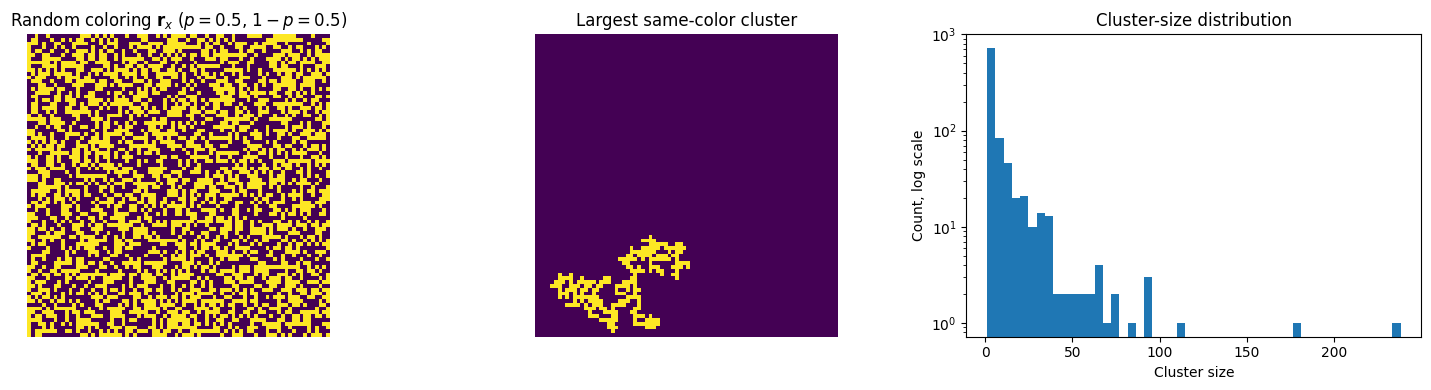

In [40]:
# ----------------------------
# Single-shot visualization
# ----------------------------

p = 0.5  # adjustable: color 1 with prob p, color 0 with prob 1-p

rng = np.random.default_rng(0)

L = 80
colors = random_coloring((L, L), p)  # r_x random coloring

roots, cluster_size_map, largest_mask, largest_size, cluster_sizes = same_color_clusters(colors)

print(f"Lattice size: {L} x {L}")
print(f"Site occupation: P(1)={p:.3f}, P(0)={1 - p:.3f}")
print(f"Number of sites: {L * L}")
print(f"Largest cluster size: {largest_size}")
print(f"Largest cluster fraction: {largest_size / (L * L):.4f}")
print(f"Number of clusters: {len(cluster_sizes)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(colors, interpolation="nearest")
axes[0].set_title(rf"Random coloring $\mathbf{{r}}_x$ ($p={p}$, $1-p={1-p:.2g}$)")
axes[0].axis("off")

axes[1].imshow(largest_mask, interpolation="nearest")
axes[1].set_title("Largest same-color cluster")
axes[1].axis("off")

axes[2].hist(cluster_sizes, bins=50)
axes[2].set_yscale("log")
axes[2].set_xlabel("Cluster size")
axes[2].set_ylabel("Count, log scale")
axes[2].set_title("Cluster-size distribution")

plt.tight_layout()
plt.show()


--- p = 0.5 ---
L= 60: largest fraction = 0.0540 ± 0.0193


L= 65: largest fraction = 0.0517 ± 0.0166
L= 70: largest fraction = 0.0399 ± 0.0104
L= 75: largest fraction = 0.0427 ± 0.0162
L= 80: largest fraction = 0.0364 ± 0.0094
L= 85: largest fraction = 0.0332 ± 0.0119
L= 90: largest fraction = 0.0342 ± 0.0108
L= 95: largest fraction = 0.0304 ± 0.0088
L=100: largest fraction = 0.0291 ± 0.0084
L=105: largest fraction = 0.0244 ± 0.0084
L=110: largest fraction = 0.0236 ± 0.0059
L=115: largest fraction = 0.0246 ± 0.0084
L=120: largest fraction = 0.0205 ± 0.0075
L=125: largest fraction = 0.0190 ± 0.0047
L=130: largest fraction = 0.0198 ± 0.0067
L=135: largest fraction = 0.0183 ± 0.0056
L=140: largest fraction = 0.0168 ± 0.0045
L=145: largest fraction = 0.0140 ± 0.0032
L=150: largest fraction = 0.0159 ± 0.0043
L=155: largest fraction = 0.0136 ± 0.0038
L=160: largest fraction = 0.0128 ± 0.0034
L=165: largest fraction = 0.0128 ± 0.0027
L=170: largest fraction = 0.0122 ± 0.0028
L=175: largest fraction = 0.0113 ± 0.0025
L=180: largest fraction = 0.0118 ±

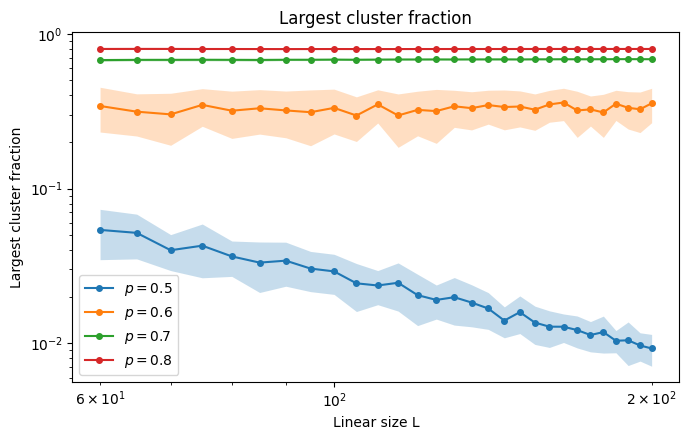

In [39]:
# ----------------------------
# Finite-size scaling demo
# ----------------------------

p_values = [0.5, 0.6, 0.7, 0.8]  # site occupation P(color=1)=p


def largest_cluster_fraction(L, p=0.5, trials=50, seed=1234):
    rng = np.random.default_rng(seed)
    fractions = []

    for _ in range(trials):
        colors = random_coloring((L, L), p, rng)
        _, _, _, largest_size, _ = same_color_clusters(colors)
        fractions.append(largest_size / (L * L))

    return np.mean(fractions), np.std(fractions)


Ls = [60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200]
Ls_arr = np.array(Ls)

fig, ax = plt.subplots(figsize=(7, 4.5))

for p_val in p_values:
    means, stds = [], []
    print(f"\n--- p = {p_val} ---")
    for L in Ls:
        mean, std = largest_cluster_fraction(L, p=p_val, trials=30)
        means.append(mean)
        stds.append(std)
        print(f"L={L:3d}: largest fraction = {mean:.4f} ± {std:.4f}")

    means_arr = np.array(means)
    stds_arr = np.array(stds)

    (line,) = ax.plot(
        Ls_arr,
        means_arr,
        "o-",
        markersize=4,
        label=rf"$p={p_val}$",
        zorder=2,
    )
    ax.fill_between(
        Ls_arr,
        np.maximum(means_arr - stds_arr, 1e-12),
        means_arr + stds_arr,
        color=line.get_color(),
        alpha=0.25,
        linewidth=0,
        zorder=1,
    )

ax.set_xlabel("Linear size L")
ax.set_ylabel("Largest cluster fraction")
ax.set_title("Largest cluster fraction")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()